# Analysis of Outcomes Data for Graduates

This project is about the analysis of outcomes data for graduates who had obtained a qualification in certain STEM subject areas from UK education providers.

#### <u> Dataset attribution statement </u>
Credit for the dataset used in this project goes to HESA (Higher Education Statistics Agency, website: www.hesa.ac.uk). The dataset is licensed under the Creative Commons Attribution 4.0 International (CC-BY-4.0) license. Please view the details for this license via the following link: https://creativecommons.org/licenses/by/4.0/legalcode.

The dataset was obtained from HESA via the following link:
https://www.hesa.ac.uk/data-and-analysis/graduates/table-30
using the 'download source data' link on the webpage. The dataset's title is: `UK permanent address graduates in full-time paid employment in the UK by subject area of degree, salary band, country of provider, provider type, level of qualification obtained, mode of former study, skill group, work population marker and academic year`.

The transformations I have applied to the dataset are stated and/ or shown within this notebook.

Please also refer to the project's README for further details about attribution and licensing.

## <u> Setup and overview <u>

In [1]:
# Import libraries and packages
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn
import warnings

In [2]:
%matplotlib inline

The following are the subject areas of interest in this analysis: `Physical sciences`, `Mathematical sciences`, `Engineering and technology`, `Computing`, and `Architecture, building and planning`.

In [3]:
# Import the dataset, including only subject areas of interest
# The source data includes tables for a range of academic years - only data for academic year 2017/18 is used below.
subject_rows_salary = range(134684, 256334) # rows containing data about subjects of interest only
header = 13 # header row index
salary_df = pd.read_csv('data/table-30-2017-18.csv', skiprows = lambda x: x not in subject_rows_salary and x != header, low_memory= False)
display(salary_df.shape)

(121650, 11)

#### Head

In [4]:
# Salary DataFrame header
salary_df.head(5)

,Subject area of degree,Country of provider,Provider type,Level of qualification obtained,Mode of former study,Skill group,Work population marker,Salary band,Academic year,Number,Percent
0,07 Physical sciences,All,All,All,All,All,Paid employment is an activity,"Less than £15,000",2017/18,95,2%
1,07 Physical sciences,All,All,All postgraduate,All,All,Paid employment is an activity,"Less than £15,000",2017/18,10,1%
2,07 Physical sciences,All,All,All undergraduate,All,All,Paid employment is an activity,"Less than £15,000",2017/18,85,3%
3,07 Physical sciences,All,All,First degree,All,All,Paid employment is an activity,"Less than £15,000",2017/18,80,3%
4,07 Physical sciences,All,All,Other undergraduate,All,All,Paid employment is an activity,"Less than £15,000",2017/18,10,5%


#### Dropping the 'Percent' column

Individual rows in this dataset represent multiple graduates. The `Number` column shows the number of graduates in a row.  The '`Percent`' column shows the quantity of graduates in a row as a percentage of graduates at all `Salary bands`, who share the same values for the remaining variables in the row.

In [5]:
# Dropping the Percent column
salary_df = salary_df.drop(columns = "Percent")

#### Discarding redundant aggregate data

The dataset consists of aggregated data.

As shown above, individual rows represent multiple graduates.

Additionally, many of the variables include an 'All' category, as shown in the value counts below. These 'All' categories are redundant and may be removed from the dataset so that only rows with more specific values for each of the variables are included.

The '`Salary band`' variable also includes a 'Total' category, which is shown in the value counts below. Rows containing this value will also be removed from the dataset.

Finally, rows containing an 'All undergraduate' or 'All postgraduate' value in the '`Level of qualification obtained`' will also be dropped.

In [6]:
salary_agg = salary_df.copy()

In [7]:
for column in salary_df:
    display(salary_df[column].value_counts())
    print("")

Subject area of degree
11 Computing                              26520
10 Engineering and technology             26160
13 Architecture, building and planning    25200
07 Physical sciences                      23940
09 Mathematical sciences                  19830
Name: count, dtype: int64

Country of provider
All                 31140
England             30660
Wales               22500
Scotland            21150
Northern Ireland    16200
Name: count, dtype: int64

Provider type
All                                  52695
Higher education providers (HEPs)    52695
Further education colleges (FECs)    16260
Name: count, dtype: int64

Level of qualification obtained
All                        21180
All undergraduate          21060
First degree               19740
Other undergraduate        18270
All postgraduate           15720
Postgraduate (taught)      15480
Postgraduate (research)    10200
Name: count, dtype: int64

Mode of former study
All          43140
Full-time    41160
Part-time    37350
Name: count, dtype: int64

Skill group
All               35910
High skilled      35850
Medium skilled    26730
Low skilled       23160
Name: count, dtype: int64

Work population marker
Paid employment is an activity                61080
Paid employment is most important activity    60570
Name: count, dtype: int64

Salary band
Less than £15,000    8110
Total                8110
£15,000 - £17,999    8110
£18,000 - £20,999    8110
£21,000 - £23,999    8110
£24,000 - £26,999    8110
£27,000 - £29,999    8110
£30,000 - £32,999    8110
£33,000 - £35,999    8110
£36,000 - £38,999    8110
£39,000 - £41,999    8110
£42,000 - £44,999    8110
£45,000 - £47,999    8110
£48,000 - £50,999    8110
£51,000+             8110
Name: count, dtype: int64

Academic year
2017/18    121650
Name: count, dtype: int64

Number
0       69695
5       16177
10       6124
15       3722
20       2951
        ...  
3300        1
3225        1
3145        1
2085        1
1345        1
Name: count, Length: 695, dtype: int64

In [8]:
# Removing rows with 'All' under any column/ variable
for column in salary_df.columns:
    rows_delete = salary_df.iloc[salary_df[column] == "All"]
    salary_df.drop(index = rows_delete.index, inplace = True)
print(f"There are now {salary_df.shape[0]} rows and {salary_df.shape[1]} columns")

There are now 17730 rows and 10 columns


In [9]:
# Removing rows with a salary band of 'Total' (i.e. aggregate of all salary bands)
rows_delete = salary_df.iloc[salary_df["Salary band"] == "Total"]
salary_df.drop(index = rows_delete.index, inplace = True)
print(f"There are now {salary_df.shape[0]} rows and {salary_df.shape[1]} columns")

There are now 16548 rows and 10 columns


In [10]:
# Removing rows with a 'Level of qualification obtained' of either 'All undergraduate' or 'All postgraduate'
rows_delete = salary_df.iloc[salary_df["Level of qualification obtained"] == "All undergraduate"]
salary_df.drop(index = rows_delete.index, inplace = True)

rows_delete = salary_df.iloc[salary_df["Level of qualification obtained"] == "All postgraduate"]
salary_df.drop(index = rows_delete.index, inplace = True)
print(f"There are now {salary_df.shape[0]} rows and {salary_df.shape[1]} columns")

There are now 10234 rows and 10 columns


#### Discarding empty rows

The dataset appears to be sparse; the value counts above show that a large number of rows have a count of 0 graduates in the '`Number`' column. Therefore, these rows do not correspond to any graduates, and can be discarded.*

\* *(Technically, these rows may correspond to 1 or 2 graduates. Numbers had been rounded to the nearest multiple of 5 by the dataset's authors, and numbers 1 and 2 had been rounded down to 0.)*

In [11]:
# Drop rows with 0 graduates
empty_rows = salary_df.iloc[salary_df["Number"] == 0]
salary_df.drop(empty_rows.index, inplace = True)
print(f"There are now {salary_df.shape[0]} rows and {salary_df.shape[1]} columns")

There are now 2116 rows and 10 columns


#### Converting variables to numerical format

In [12]:
# Converting 'Academic year' to numerical format (date)
salary_df["Academic year"] = salary_df["Academic year"].str.replace("2017/18", "2017") # replacing the academic year's year range with its start year
salary_df["Academic year"] = salary_df["Academic year"].astype("datetime64[ns]")  # converting string to the datetime64 format
salary_df["Academic year"] = salary_df["Academic year"].apply(lambda x: x.year)  # keeping only the year of the date object (converts to int64 format)

To convert `Salary band` to numerical format, each salary band is replaced with its midpoint, as shown below.

In [13]:
# Converting 'Salary band' to numerical format, using midpoints of each band
salary_band_dict = {}

for band in salary_df["Salary band"].unique():
    band_processed = band.split(" - ") # splits value into two: upper and lower values of band
    band_processed = [val.replace("£", "").replace(",", "").strip() for val in band_processed] # strips '£' symbol, commas and whitespace
    # all bands besides highest and lowest
    if len(band_processed) == 2:
        sal_midpoint = (int(band_processed[0]) + int(band_processed[1])) // 2
    # lowest band
    elif band_processed[0] == "Less than 15000": # threshold used
        sal_midpoint = 14999
    # highest band
    elif band_processed[0] == "51000+": # threshold used
        sal_midpoint = 51000
    else:
        print("error", band_processed)
    salary_band_dict[band] = sal_midpoint # add original & processed values to dict as key, value pair

display(salary_band_dict)

{'£18,000 - £20,999': 19499,
 'Less than £15,000': 14999,
 '£15,000 - £17,999': 16499,
 '£21,000 - £23,999': 22499,
 '£24,000 - £26,999': 25499,
 '£27,000 - £29,999': 28499,
 '£30,000 - £32,999': 31499,
 '£33,000 - £35,999': 34499,
 '£36,000 - £38,999': 37499,
 '£39,000 - £41,999': 40499,
 '£42,000 - £44,999': 43499,
 '£45,000 - £47,999': 46499,
 '£48,000 - £50,999': 49499,
 '£51,000+': 51000}

In the newly-created `salary_band_dict`, the keys show the original salary band, and the values show either the midpoints of the corresponding salary band, or, for highest and lowest salary bands only, the threshold value of the salary band.

Note: In the dataset, graduates earning salaries of £51,000 and higher had been grouped into one category as '£51,000+', while those earning up to £15,000 had been grouped into another category as 'Less than £15,000', i.e. the data is right- and left-censored.<br>

In [14]:
# Converting 'Salary band' to numerical format (cont.)
salary_df_copy = salary_df.replace(to_replace = salary_band_dict) # replaces salary band ranges with midpoints (or thresholds, for highest and lowest bands)
salary_df_copy["Salary band"] = salary_df_copy["Salary band"].astype("Int64") # 'Salary band' column converted from 'object' to Int datatype
salary_df_copy.rename(columns = {"Salary band" : "Salary band midpoint/ threshold"}, inplace = True) # 'Salary band' column renamed to 'Salary band midpoint/ threshold'

#### Variable information

In [15]:
# Viewing data types and non-null counts:
salary_df_copy.info()

<class 'pandas.DataFrame'>
Index: 2116 entries, 9438 to 121330
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Subject area of degree           2116 non-null   str  
 1   Country of provider              2116 non-null   str  
 2   Provider type                    2116 non-null   str  
 3   Level of qualification obtained  2116 non-null   str  
 4   Mode of former study             2116 non-null   str  
 5   Skill group                      2116 non-null   str  
 6   Work population marker           2116 non-null   str  
 7   Salary band midpoint/ threshold  2116 non-null   Int64
 8   Academic year                    2116 non-null   int64
 9   Number                           2116 non-null   int64
dtypes: Int64(1), int64(2), str(7)
memory usage: 474.4 KB


#### Summary statistics: numerical variables

The three columns with numerical data are currently '`Academic year`', '`Number`' and '`Salary band midpoint/ threshold`'. <br>

In [16]:
# Summary statistics
stat_summary = salary_df_copy.describe()
display(stat_summary)
print(f"NB: the 'min' and 'max' values for 'Salary band midpoint/ threshold' have been censored")

,Salary band midpoint/ threshold,Academic year,Number
count,2116.0,2116.0,2116.000000
mean,30344.995274,2017.0,27.199905
std,10752.623079,0.0,76.792787
min,14999.0,2017.0,5.000000
25%,22499.0,2017.0,5.000000
50%,28499.0,2017.0,5.000000
75%,37499.0,2017.0,20.000000
max,51000.0,2017.0,1225.000000


NB: the 'min' and 'max' values for 'Salary band midpoint/ threshold' have been censored


All rows in this dataset have the same `Academic year`, as expected. <br> <br>
The summary statistics above for `Salary band midpoint` currently do not take into account the `Number` of graduates in each salary band, as the data is currently aggregated. More useful summary statistics may be obtained by disaggregating the data. <br><br>
The maximum `Number` of graduates in a single row is 1225. To check the validity of this large `Number` value, the largest unique `Number` values were examined. A few unique '`Number`' values were larger than 900. The DataFrame was queried to find row with a large `Number` of graduates, which shows that the top three rows (in terms of number of graduates) consist of graduates whose first degree was in Engineering and Technology.

In [17]:
# Top three largest groups of graduates
number_values = sorted(salary_df_copy["Number"].unique(), reverse = True)[0:3]
display(number_values)
salary_df_copy.query("Number == @number_values")

[np.int64(1225), np.int64(1210), np.int64(980)]

,Subject area of degree,Country of provider,Provider type,Level of qualification obtained,Mode of former study,Skill group,Work population marker,Salary band midpoint/ threshold,Academic year,Number
54975,10 Engineering and technology,England,Higher education providers (HEPs),First degree,Full-time,High skilled,Paid employment is an activity,28499,2017,1225
54982,10 Engineering and technology,England,Higher education providers (HEPs),First degree,Full-time,High skilled,Paid employment is an activity,31499,2017,980
55080,10 Engineering and technology,England,Higher education providers (HEPs),First degree,Full-time,High skilled,Paid employment is most important activity,28499,2017,1210


#### Histograms

In [18]:
salary_plot = salary_df_copy.copy()

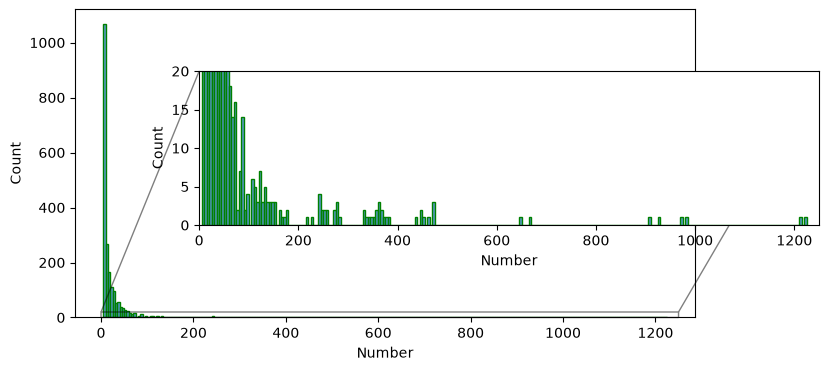

In [19]:
# Histogram: Numbers
warnings.filterwarnings("ignore", category=UserWarning)

fig_num, ax1 = plt.subplots(figsize=(8, 4), sharex=True)
sns.histplot(data=salary_plot["Number"], ax=ax1, binwidth=5, edgecolor="green", linewidth =1) # base plot

inset = ax1.inset_axes([0.2, 0.3, 1, 0.5], xlim=(0, 1250), ylim=(0, 20)) # zoomed plot
sns.histplot(data=salary_plot["Number"], ax=inset, binwidth=5, edgecolor="green", linewidth=1)
ax1.indicate_inset_zoom(inset, edgecolor="black")

for axis in (ax1, inset): # set spine edge colour
    for spine in axis.spines.values():
        spine.set_edgecolor("black")
fig_num.show()

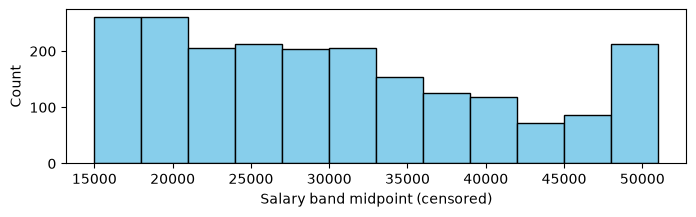

In [20]:
# Histogram: Salary band midpoint
fig_sal, ax = plt.subplots(figsize=(8, 2))
sns.histplot(data=salary_plot, x = salary_plot["Salary band midpoint/ threshold"], binwidth=3000, color = "skyblue", ax=ax, alpha=1)
ax.set(xlabel="Salary band midpoint (censored)")
for spine in ax.spines.values():
    spine.set_edgecolor("black")
fig_sal.show()

The histogram plot of the `Number` variable shows the number of graduates for each row. The most common value for `Number` is 5, indicating that the vast majority of rows had only 5 graduates (numbers had been rounded to the nearest 5 by the dataset authors, therefore each row with `Number` = 5 may correspond to as few as 3 and as many as 7 graduates). However, as shown in the histogram and in the rows returned by the DataFrame query, a few rows had a much higher number of graduates (approx. 1000-1200). Some of these rows correspond to graduates whose first degree was in `Engineering and technology`, and whose salary was close to the median. <br><br>
As all rows represent a group of graduates, the `Salary band midpoint (censored)` data currently shows the count of groups, i.e. rows, with each salary band. (A group may correspond to between 3 and 1227 graduates.)